# Task 3 Exploiting Correlation

## Objective
- Pick government securities from one country
- F

### Simulation of Uncorrelated Gaussian Yield Changes
To understand the statistical behavior of yield dynamics, it is essential to begin with a controlled simulation of uncorrelated random variables.

In this project, we generate five independent Gaussian distributed yield changes with a mean close to zero and a small standard deviation, representing modestsmall daily fluctuations in yields.

In [43]:
import numpy as np
import pandas as pd


np.random.seed(42)

n_obs = 100
n_vars = 5
mean = 0.0
std_dev = 0.02

data = np.random.normal(loc=mean, scale=std_dev, size=(n_obs, n_vars))

columns = [f"Yield_Change_{i+1}" for i in range(n_vars)]
df = pd.DataFrame(data, columns=columns)

print("Sample of simulated yield changes:")
print(df.head(), "\n")




Sample of simulated yield changes:
   Yield_Change_1  Yield_Change_2  Yield_Change_3  Yield_Change_4  \
0        0.009934       -0.002765        0.012954        0.030461   
1       -0.004683        0.031584        0.015349       -0.009389   
2       -0.009268       -0.009315        0.004839       -0.038266   
3       -0.011246       -0.020257        0.006285       -0.018160   
4        0.029313       -0.004516        0.001351       -0.028495   

   Yield_Change_5  
0       -0.004683  
1        0.010851  
2       -0.034498  
3       -0.028246  
4       -0.010888   



In [44]:
correlation_matrix = df.corr()
print("Correlation matrix:")
print(correlation_matrix)

Correlation matrix:
                Yield_Change_1  Yield_Change_2  Yield_Change_3  \
Yield_Change_1        1.000000       -0.163433        0.044866   
Yield_Change_2       -0.163433        1.000000        0.122764   
Yield_Change_3        0.044866        0.122764        1.000000   
Yield_Change_4       -0.101832        0.038215        0.008525   
Yield_Change_5       -0.126184        0.057155        0.042819   

                Yield_Change_4  Yield_Change_5  
Yield_Change_1       -0.101832       -0.126184  
Yield_Change_2        0.038215        0.057155  
Yield_Change_3        0.008525        0.042819  
Yield_Change_4        1.000000        0.018358  
Yield_Change_5        0.018358        1.000000  


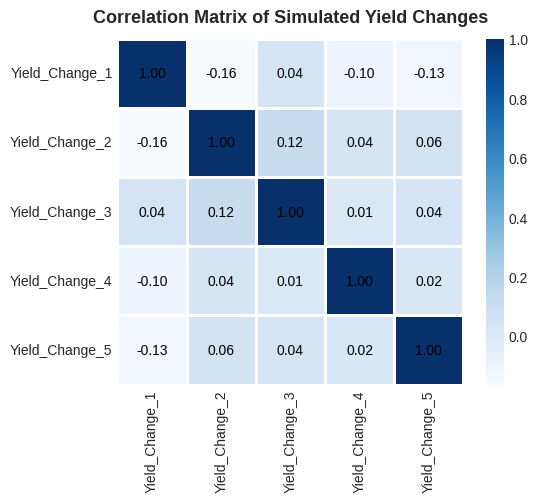

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df.corr()

plt.style.use("seaborn-v0_8-white")

plt.figure(figsize=(6, 5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True,
    square=True,
    linewidths=0.8,
    linecolor="white",
    annot_kws={"fontsize": 10, "color": "black"}
)

plt.title("Correlation Matrix of Simulated Yield Changes", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


PCA based on the Correlation Matrix:

Principal Component 1: 0.2571
Principal Component 2: 0.2127
Principal Component 3: 0.1955
Principal Component 4: 0.1846
Principal Component 5: 0.1501


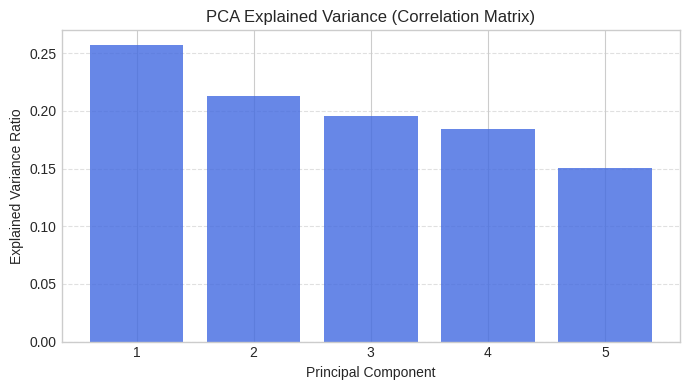

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


np.random.seed(42)

n_obs = 100
n_vars = 5
mean = 0.0
std_dev = 0.02

data = np.random.normal(loc=mean, scale=std_dev, size=(n_obs, n_vars))
columns = [f"Yield_Change_{i+1}" for i in range(n_vars)]
df = pd.DataFrame(data, columns=columns)


use_matrix = "correlation"

if use_matrix == "correlation":
    scaler = StandardScaler()
    df_input = scaler.fit_transform(df)
    matrix_used = "Correlation Matrix"
else:
    df_input = df.values
    matrix_used = "Covariance Matrix"


pca = PCA()
pca.fit(df_input)

explained_variance = pca.explained_variance_ratio_

print(f"PCA based on the {matrix_used}:\n")
for i, ev in enumerate(explained_variance, start=1):
    print(f"Principal Component {i}: {ev:.4f}")

plt.figure(figsize=(7,4))
plt.bar(range(1, n_vars+1), explained_variance, color='royalblue', alpha=0.8)
plt.title(f"PCA Explained Variance ({matrix_used})")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1, n_vars+1))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [54]:

explained_variance = pca.explained_variance_ratio_

var_comp1 = explained_variance[0]
var_comp2 = explained_variance[1]
var_comp3 = explained_variance[2]
total_var_3 = var_comp1 + var_comp2 + var_comp3

print(f"\nVariance Explained by Each Component ({matrix_used}):")
print(f"Component 1: {var_comp1:.4%}")
print(f"Component 2: {var_comp2:.4%}")
print(f"Component 3: {var_comp3:.4%}")
print(f"Total Variance Explained by First 3 Components: {total_var_3:.4%}")



Variance Explained by Each Component (Correlation Matrix):
Component 1: 25.7080%
Component 2: 21.2724%
Component 3: 19.5483%
Total Variance Explained by First 3 Components: 66.5287%


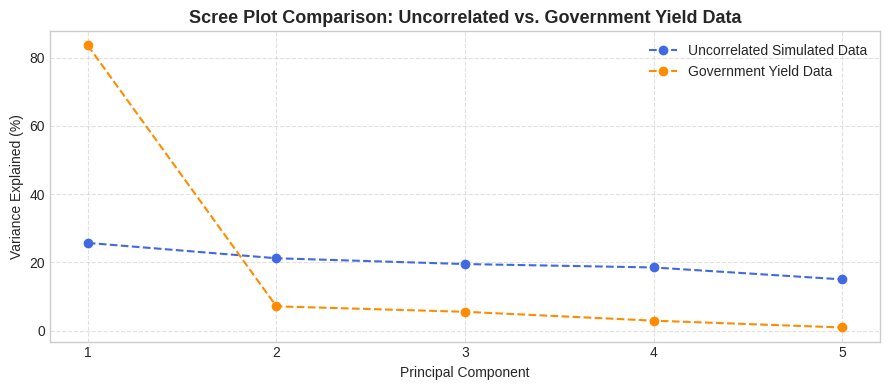

In [58]:
import matplotlib.pyplot as plt

components = [1, 2, 3, 4, 5]
uncorr_explained = [25.7, 21.2, 19.5, 18.5, 15.0]
gov_explained = [83.6, 7.1, 5.5, 2.9, 0.9]

plt.figure(figsize=(9, 4))

plt.plot(components, uncorr_explained, 'o--', color='royalblue', label="Uncorrelated Simulated Data")
plt.plot(components, gov_explained, 'o--', color='darkorange', label="Government Yield Data")

plt.title("Scree Plot Comparison: Uncorrelated vs. Government Yield Data", fontsize=13, fontweight="bold")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.xticks(components)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


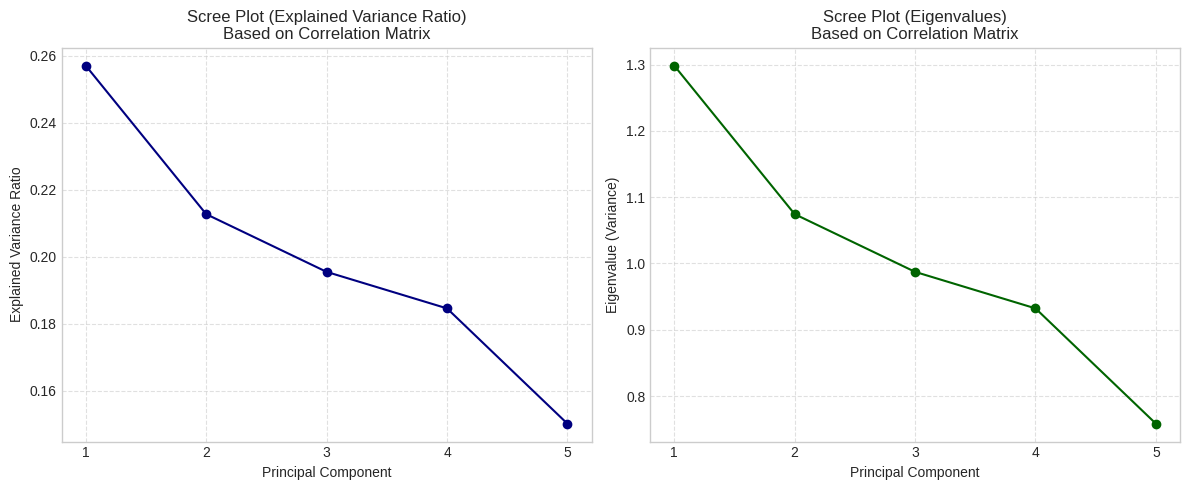

Variance Explained by Each Component:
  Component  Explained_Variance_Ratio  Eigenvalue
0       PC1                  0.257080    1.298383
1       PC2                  0.212724    1.074362
2       PC3                  0.195483    0.987289
3       PC4                  0.184575    0.932199
4       PC5                  0.150138    0.758272


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n_obs = 100
n_vars = 5
mean = 0.0
std_dev = 0.02

data = np.random.normal(loc=mean, scale=std_dev, size=(n_obs, n_vars))
columns = [f"Yield_Change_{i+1}" for i in range(n_vars)]
df = pd.DataFrame(data, columns=columns)

use_matrix = "correlation"

if use_matrix == "correlation":
    scaler = StandardScaler()
    df_input = scaler.fit_transform(df)
    matrix_label = "Correlation"
else:
    df_input = df.values
    matrix_label = "Covariance"

pca = PCA()
pca.fit(df_input)

explained_variance_ratio = pca.explained_variance_ratio_
eigenvalues = pca.explained_variance_

components = np.arange(1, len(explained_variance_ratio) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(components, explained_variance_ratio, 'o-', color='navy')
plt.title(f"Scree Plot (Explained Variance Ratio)\nBased on {matrix_label} Matrix")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(components)
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(components, eigenvalues, 'o-', color='darkgreen')
plt.title(f"Scree Plot (Eigenvalues)\nBased on {matrix_label} Matrix")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue (Variance)")
plt.xticks(components)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

var_explained = pd.DataFrame({
    'Component': [f'PC{i}' for i in components],
    'Explained_Variance_Ratio': explained_variance_ratio,
    'Eigenvalue': eigenvalues
})
print("Variance Explained by Each Component:")
print(var_explained)


In [2]:
# Install required package if not already installed
!pip install pandas_datareader --quiet

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
from sklearn.decomposition import PCA

# Set display and plotting preferences
plt.style.use("seaborn-v0_8-whitegrid")


In [3]:
# Define FRED tickers for 5 maturities
tickers = ["DGS1MO", "DGS3MO", "DGS2", "DGS5", "DGS10"]

# Fetch 6 months of daily data
yields = pdr.DataReader(tickers, 'fred', start='2025-04-01')

# Drop missing values (some days no trading)
yields = yields.dropna()

print("Data Retrieved Successfully")
print(yields.head())


Data Retrieved Successfully
            DGS1MO  DGS3MO  DGS2  DGS5  DGS10
DATE                                         
2025-04-01    4.38    4.32  3.87  3.91   4.17
2025-04-02    4.38    4.32  3.91  3.95   4.20
2025-04-03    4.36    4.31  3.71  3.75   4.06
2025-04-04    4.36    4.28  3.68  3.72   4.01
2025-04-07    4.36    4.29  3.73  3.82   4.15


In [4]:
print(yields)

            DGS1MO  DGS3MO  DGS2  DGS5  DGS10
DATE                                         
2025-04-01    4.38    4.32  3.87  3.91   4.17
2025-04-02    4.38    4.32  3.91  3.95   4.20
2025-04-03    4.36    4.31  3.71  3.75   4.06
2025-04-04    4.36    4.28  3.68  3.72   4.01
2025-04-07    4.36    4.29  3.73  3.82   4.15
...            ...     ...   ...   ...    ...
2025-09-30    4.20    4.02  3.60  3.74   4.16
2025-10-01    4.17    4.01  3.55  3.68   4.12
2025-10-02    4.23    4.02  3.55  3.67   4.10
2025-10-03    4.24    4.03  3.58  3.72   4.13
2025-10-06    4.22    4.02  3.60  3.75   4.18

[130 rows x 5 columns]


In [5]:
# Compute daily yield changes (Δy_t = y_t - y_(t-1))
yield_changes = yields.diff().dropna()

print("Daily yield changes (in % points):")
print(yield_changes.head())


Daily yield changes (in % points):
            DGS1MO  DGS3MO  DGS2  DGS5  DGS10
DATE                                         
2025-04-02    0.00    0.00  0.04  0.04   0.03
2025-04-03   -0.02   -0.01 -0.20 -0.20  -0.14
2025-04-04    0.00   -0.03 -0.03 -0.03  -0.05
2025-04-07    0.00    0.01  0.05  0.10   0.14
2025-04-08    0.00    0.02 -0.02  0.06   0.11


In [6]:
# Run PCA
pca = PCA()
pca.fit(yield_changes)

# Explained variance ratio (in %)
explained_var = pca.explained_variance_ratio_ * 100

# Print results
for i, var in enumerate(explained_var, 1):
    print(f"Component {i}: {var:.2f}% variance explained")


Component 1: 83.64% variance explained
Component 2: 7.10% variance explained
Component 3: 5.50% variance explained
Component 4: 2.86% variance explained
Component 5: 0.90% variance explained


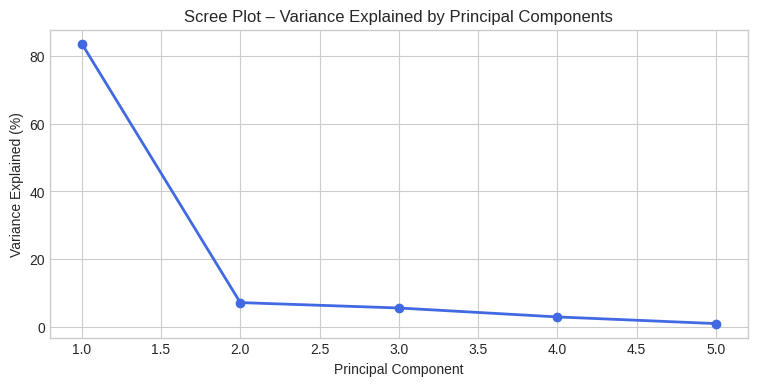

In [52]:
#Scree Plot

plt.figure(figsize=(9,4))
plt.plot(range(1, len(explained_var)+1), explained_var, 'o-', color='royalblue', linewidth=2)
plt.title("Scree Plot – Variance Explained by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.show()


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



uncorr_explained = np.array([25.71, 21.27, 19.55, 18.46, 15.01])  # in %
uncorr_labels = [f"PC{i}" for i in range(1, 6)]

gov_explained = np.array([83.64, 7.10, 5.50, 2.86, 0.90])  # in %

comparison_df = pd.DataFrame({
    "Component": uncorr_labels,
    "Uncorrelated_Data (%)": uncorr_explained,
    "Government_Data (%)": gov_explained
})

print("Variance Explained Comparison:\n")
print(comparison_df.to_string(index=False))

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(8, 5))

components = np.arange(1, 6)

Variance Explained Comparison:

Component  Uncorrelated_Data (%)  Government_Data (%)
      PC1                  25.71                83.64
      PC2                  21.27                 7.10
      PC3                  19.55                 5.50
      PC4                  18.46                 2.86
      PC5                  15.01                 0.90


<Figure size 800x500 with 0 Axes>

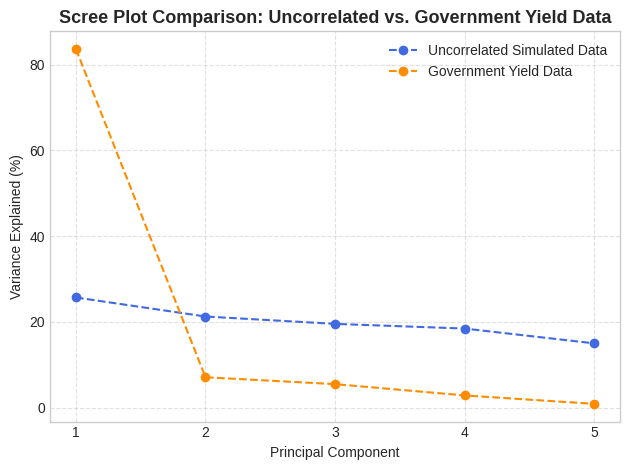

In [47]:
# Plot both scree plots
plt.plot(components, uncorr_explained, 'o--', color='royalblue', label="Uncorrelated Simulated Data")
plt.plot(components, gov_explained, 'o--', color='darkorange', label="Government Yield Data")

# Formatting
plt.title("Scree Plot Comparison: Uncorrelated vs. Government Yield Data", fontsize=13, fontweight="bold")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.xticks(components)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


we’ll compare:

This real yield data scree plot
vs
The uncorrelated Gaussian data scree plot (from part 1, which we’ve to do next).